<a href="https://colab.research.google.com/github/Ag11335/Taller1/blob/main/YullyCadena_AnaGarzon_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laboratorio 1

### 1. A partir de la información brindada, el área de análisis de crédito de un banco desea determinar cuál es el modelo que minimiza el porcentaje de falsos positivos (clientes clasificados como de baja calificación crediticia).

Calcule el % de falsos positivos para un modelo determinado Falsos Positivos / Número total de observaciones.

    a. Desarrolle los modelos de regresión logística, Árbol de decisión y Random Forest con el set de datos entregado.
    b. Determine cuál es el modelo que minimiza la tasa de falsos positivos consistentemente. (Clientes "buenos clasificados como malos" / total clientes analizados)
    c. ¿Qué pasa con la tasa de falsos negativos con el modelo encontrado en el punto b? Describa los resultados
    d. ¿Cuál es la implicación para el banco en términos de riesgos del resultado obtenido y el análisis realizado en el punto c? Analice
    
  NOTA: Importante evaluar la consistencia y baja varianza del modelo

### 2. La vicepresidencia comercial del Banco sugiere que se tienen metas muy altas en términos de colocación de créditos, a lo que el Vicepresidente Financiero agrega que hay excedentes de liquidez muy altos y que en estas condiciones puede justificarse asumir algo más de riesgo del que el modelo sugiere.

Como proponente del modelo ¿qué cambios sugeriría para que el modelo arroje resultados más "permisivos"?

Tenga en cuenta que este tipo de modelos pueden arrojar la clasificación, pero también la probabilidad de que un elemento pertenezca a una clase.

Revise la función predict_proba del modelo que encontró en el punto 1 y modifique los resultados de clasificación, teniendo en cuenta que por defecto, un cliente cuya probabilidad de no pagar es del 51%, será clasificado como mal cliente, y le será negado el crédito y recuerde que usted quiere ser más permisivo.https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.predict_proba

### 3. La Vicepresidente de Riesgos no está muy contenta con la propuesta y menciona que por cada 100 solicitudes aleatorias de crédito X van a ser clientes que incumplan sus créditos.

¿Cuánto vale X? Justifique su respuesta.

### Entregue este laboratorio en parejas a través del Aula Virtual en formato PDF o HTML.
Asegúrese de que el archivo entregado se pueda abrir bien. En el caso de archivos HTML haga la prueba de abrirlo en algún navegador.

In [1]:
##Librerias
%pip install https://github.com/ydataai/pandas-profiling/archive/master.zip
from pandas_profiling import ProfileReport
import pandas as pd
import numpy as np
import sys
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import itertools
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn import linear_model


     / 17.8 MB 37.0 MB/s 0:00:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 26.0 MB/s eta 0:00:00
  Created wheel for ydata-profiling: filename=ydata_profiling-0.0.dev0-py2.py3-none-any.whl size=356222 sha256=63a530f84eb1a4d38375a086ef86003dffab5822449982064e9cac95bcae17bc
  Stored in directory: /tmp/pip-ephem-wheel-cache-9kb1id0d/wheels/f5/4e/04/09011c49d76834ce963a4fe57acc90b11fa8bb282bb9781d97
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=c662aca440637d580a9e0ddc67cec3b50d50567b36a8119ff54c7077bc11ce81
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Succe

<ipython-input-1-fa5c51cd249d>:3: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


## Datos

In [2]:
source = 'https://raw.githubusercontent.com/nparis87/MachineLearning/main/CreditQuality.csv'

data = pd.read_csv(source, sep=';')

data.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column12,Column13,Column14,Column15,Column16,Column17,Column18,Column19,Column20,Column21
0,11,6,34,43,1169,65,75,4,93,101,...,121,67,143,152,2,173,1,192,201,0
1,12,48,32,43,5951,61,73,2,92,101,...,121,22,143,152,1,173,1,191,201,1
2,14,12,34,46,2096,61,74,2,93,101,...,121,49,143,152,1,172,2,191,201,0
3,11,42,32,42,7882,61,74,2,93,103,...,122,45,143,153,1,173,2,191,201,0
4,11,24,33,40,4870,61,73,3,93,101,...,124,53,143,153,2,173,2,191,201,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Column1   1000 non-null   int64
 1   Column2   1000 non-null   int64
 2   Column3   1000 non-null   int64
 3   Column4   1000 non-null   int64
 4   Column5   1000 non-null   int64
 5   Column6   1000 non-null   int64
 6   Column7   1000 non-null   int64
 7   Column8   1000 non-null   int64
 8   Column9   1000 non-null   int64
 9   Column10  1000 non-null   int64
 10  Column11  1000 non-null   int64
 11  Column12  1000 non-null   int64
 12  Column13  1000 non-null   int64
 13  Column14  1000 non-null   int64
 14  Column15  1000 non-null   int64
 15  Column16  1000 non-null   int64
 16  Column17  1000 non-null   int64
 17  Column18  1000 non-null   int64
 18  Column19  1000 non-null   int64
 19  Column20  1000 non-null   int64
 20  Column21  1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [4]:
data.isna().sum()

,0
Column1,0
Column2,0
Column3,0
Column4,0
Column5,0
Column6,0
Column7,0
Column8,0
Column9,0
Column10,0


In [5]:
print(data.shape)


(1000, 21)


In [6]:
data.drop_duplicates(inplace=True)
print(data.shape)

(1000, 21)


In [7]:
ProfileReport(data)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
data_dummy= pd.get_dummies(data)
data_dummy.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column12,Column13,Column14,Column15,Column16,Column17,Column18,Column19,Column20,Column21
0,11,6,34,43,1169,65,75,4,93,101,...,121,67,143,152,2,173,1,192,201,0
1,12,48,32,43,5951,61,73,2,92,101,...,121,22,143,152,1,173,1,191,201,1
2,14,12,34,46,2096,61,74,2,93,101,...,121,49,143,152,1,172,2,191,201,0
3,11,42,32,42,7882,61,74,2,93,103,...,122,45,143,153,1,173,2,191,201,0
4,11,24,33,40,4870,61,73,3,93,101,...,124,53,143,153,2,173,2,191,201,1


In [9]:
col_ind= list(data_dummy.columns)
col_ind.remove("Column21")#quitar variable dependiente
col_ind

['Column1',
 'Column2',
 'Column3',
 'Column4',
 'Column5',
 'Column6',
 'Column7',
 'Column8',
 'Column9',
 'Column10',
 'Column11',
 'Column12',
 'Column13',
 'Column14',
 'Column15',
 'Column16',
 'Column17',
 'Column18',
 'Column19',
 'Column20']

In [10]:
#Crear variable y y x
X= data_dummy[col_ind]
Y= data_dummy["Column21"]

In [11]:
#Dividir datos
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, random_state = 20)
display(X.head())

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14,Column15,Column16,Column17,Column18,Column19,Column20
0,11,6,34,43,1169,65,75,4,93,101,4,121,67,143,152,2,173,1,192,201
1,12,48,32,43,5951,61,73,2,92,101,2,121,22,143,152,1,173,1,191,201
2,14,12,34,46,2096,61,74,2,93,101,3,121,49,143,152,1,172,2,191,201
3,11,42,32,42,7882,61,74,2,93,103,4,122,45,143,153,1,173,2,191,201
4,11,24,33,40,4870,61,73,3,93,101,4,124,53,143,153,2,173,2,191,201


LOG


In [12]:
reg_log=linear_model.LogisticRegression(multi_class='multinomial',
solver='lbfgs',max_iter=1000)
reg_log.fit(X_train,Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [13]:
cm1= confusion_matrix(Y_test, reg_log.predict(X_test))
cm1

array([[140,  19],
       [ 59,  32]])

ARBOL DE DECISIÓN

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
modelo_arbol = DecisionTreeClassifier(max_depth = 10)
modelo_arbol.fit(X_train,Y_train)


DecisionTreeClassifier(max_depth=10)

In [15]:
cm2= confusion_matrix(Y_test, modelo_arbol.predict(X_test))
cm2

array([[133,  26],
       [ 53,  38]])

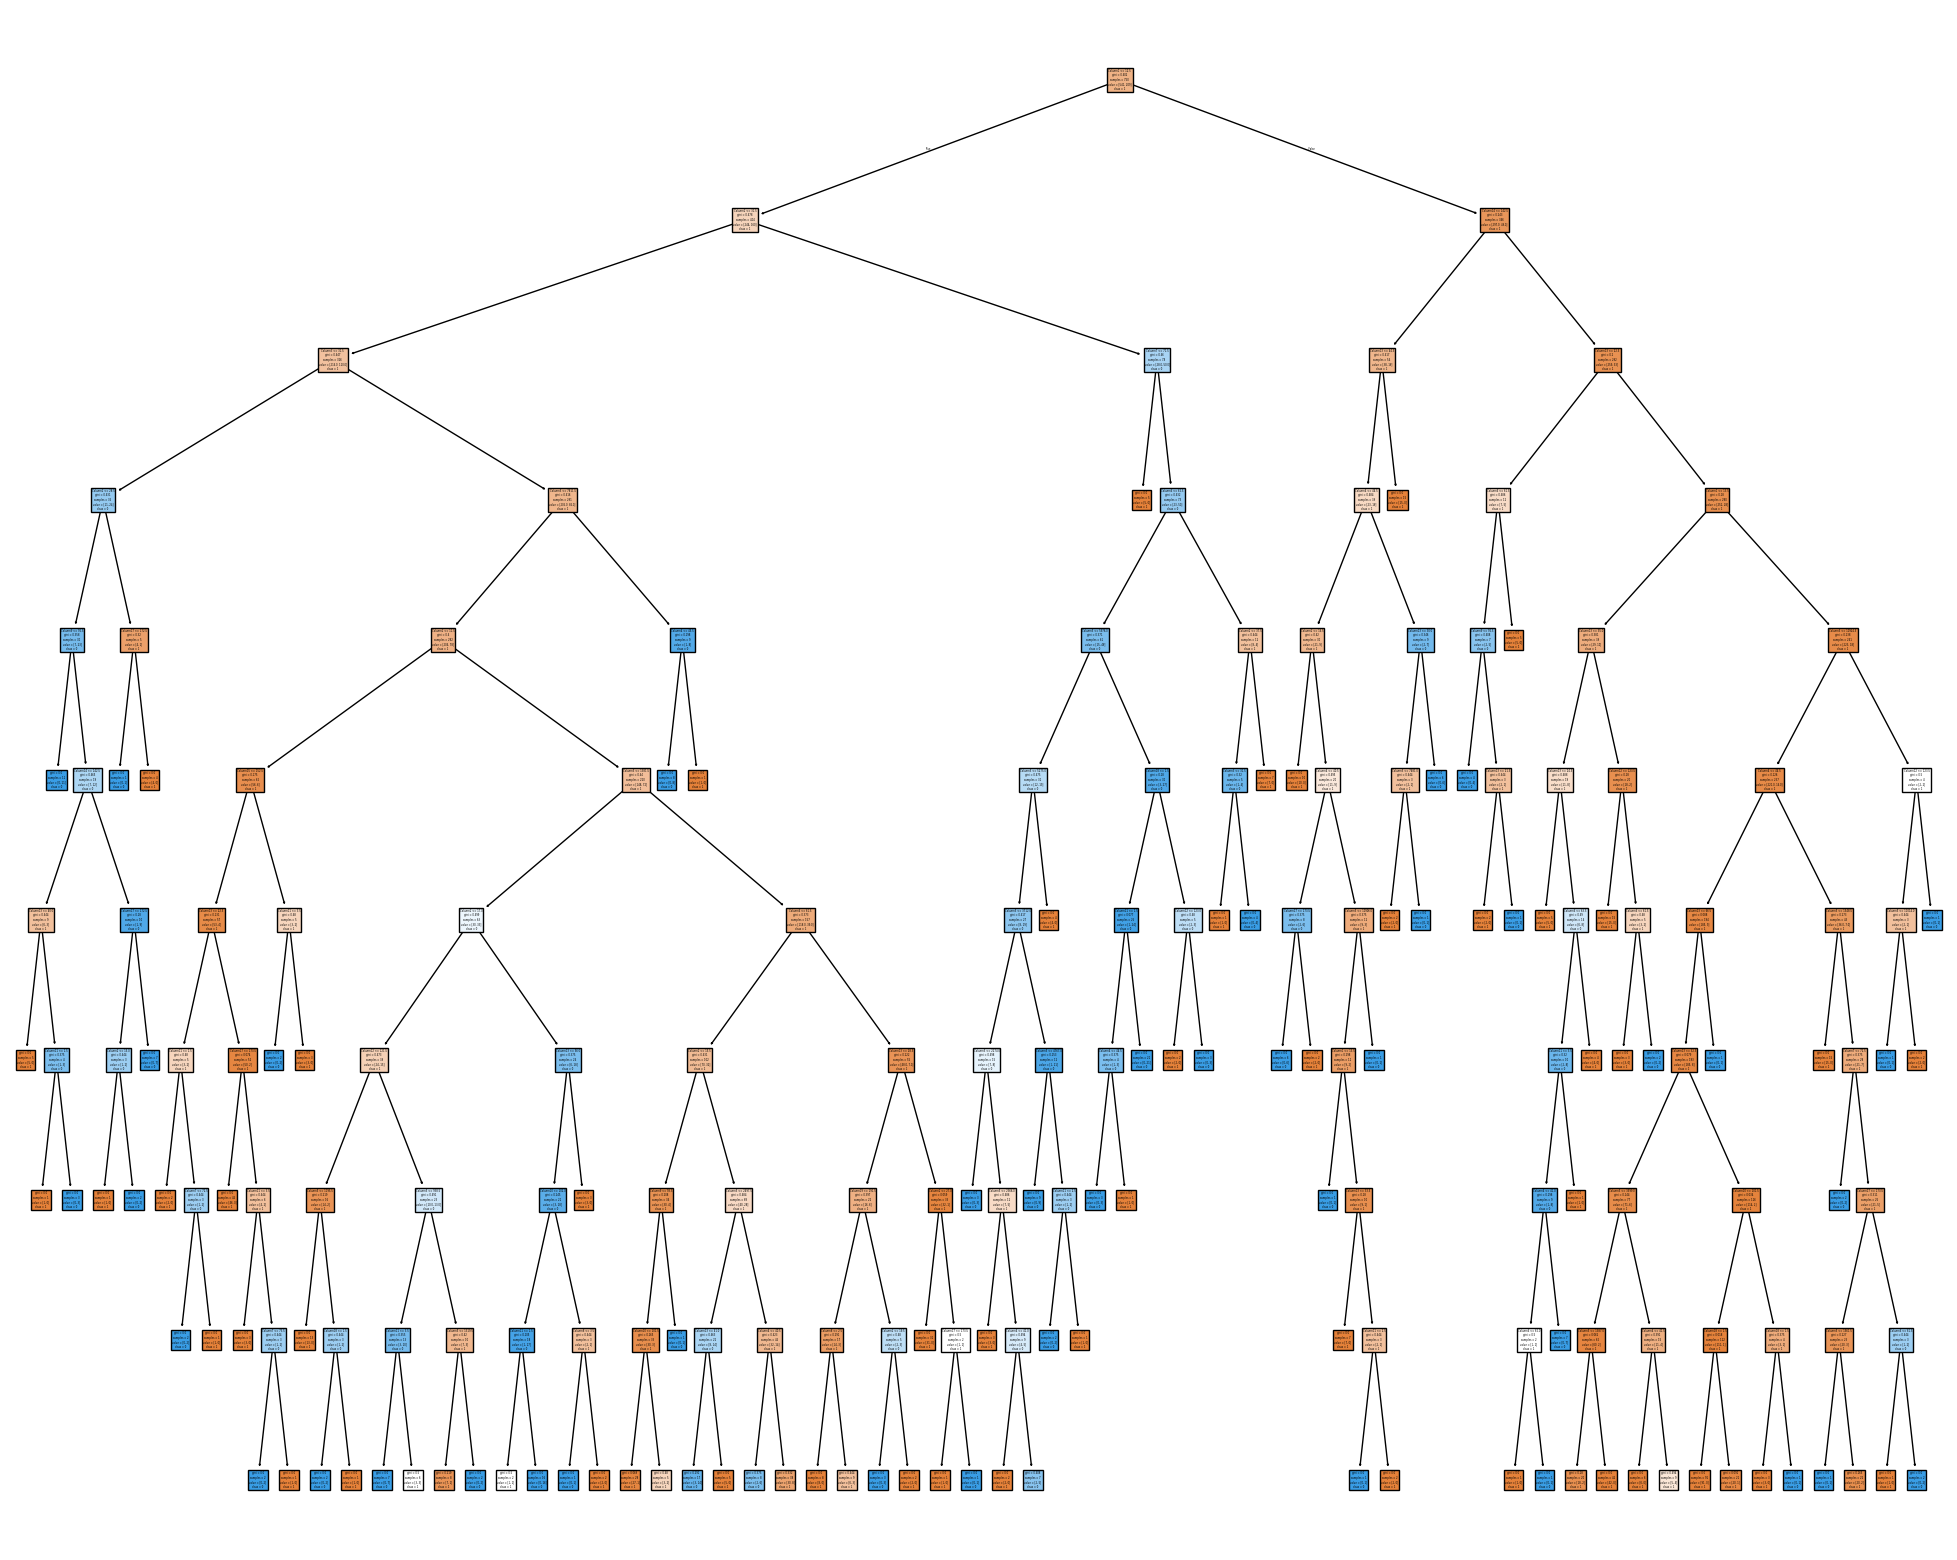

In [16]:
fig = plt.figure(figsize=(25,20))
arbol = plot_tree(modelo_arbol,
feature_names=X_train.columns,
class_names=Y_train.unique().astype(int).astype(str).tolist(),
filled=True)


KNN


In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5,weights="distance") #es mejor no usar numeros pares #si no le pongo nada a los pesos, va a tomar
knn.fit(X_train, Y_train)


KNeighborsClassifier(weights='distance')

In [18]:
cm3= confusion_matrix(Y_test, knn.predict(X_test))
cm3

array([[143,  16],
       [ 73,  18]])

RATIO



In [19]:
# Ratio log
log=17/250
log*100


6.800000000000001

In [20]:
# Ratio Arbol de Decisión
arb=29/250
arb*100

11.600000000000001

In [21]:
# Ratio de KNN
knn=16/250
knn*100


6.4

b). Como se puede evidenciar, el modelo que minimiza de mejor forma los falsos positivos es el modelo de KNN con un 6,4%.
c) Explicación:
En el modelo KNN es menos propenso a clasificar incorrectamente un caso positivo como negativo, ya que la probabilidad de que sea
negativo es baja. En este caso, de cada 100 clientes, el modelo clasifica incorrectamente a 6,4 como de baja calificación crediticia. Esto
significa que el banco podría otorgar un préstamo a un cliente que en realidad no debería tener uno, lo que podría generar pérdidas para el
banco.

La regresión logística es más propensa a que existan tasas de falsos negativos más altas. En este caso, de cada 100 clientes clasifica
correctamente a 93,2 clientes como de buena calificación crediticia y clasifica incorrectamente a 6,8 clientes como de baja calificación
crediticia.Esto significa que el banco podría otorgar más préstamos a clientes que no deberían.

El árbol de decisión tiene una tasa de falsos positivos mucho más alta que el KNN y la regresión logística. Esto significa que e es mucho
más propenso a clasificar incorrectamente a un cliente como de baja calificación crediticia cuando no es.De cada 100 clientes, clasifica
correctamente a 88,4 clientes como de buena calificación crediticia y clasifica incorrectamente a 11,6 clientes Es decir, da un préstamo a
11,6 clientes que no debería.

d) El área de análisis de crédito del banco debe elegir el modelo KNN, ya que minimiza el riesgo de otorgar préstamos a clientes que en realidad
no deberían tenerlos, ya que tienen una calificación baja y podrian hacer default y generar pérdidas para el banco

2. Usaremos el modelo de regresión logística ya que es el que minimiza la tasa de falsos positivos. Podemos modificar la probabilidad de corte para clasificar a un cliente como "malo". por defecto la probabilidad de corte es 0.5. Si la probabilidad de no pagar es mayor a 0.5 el cliente es clasificado como "malo"

In [22]:
probabilidades = reg_log.predict_proba(X_test)


In [23]:
umbral = 0.4
predicciones_permisivas = (probabilidades[:, 1] > umbral).astype(int)

In [24]:
cm_permisiva = confusion_matrix(Y_test, predicciones_permisivas)
print(cm_permisiva)

[[133  26]
 [ 40  51]]


In [25]:
nuevos_falsos_positivos = cm_permisiva[0, 1]
total_observaciones = cm_permisiva.sum()
nueva_tasa_fp = nuevos_falsos_positivos / total_observaciones * 100

print(f"La nueva tasa de falsos positivos es: {nueva_tasa_fp:.2f}%")

La nueva tasa de falsos positivos es: 10.40%


3 Punto


In [26]:
y_test_np = np.array(Y_test)
total_clientes = len(y_test_np)
clientes_incumplido = np.sum(y_test_np == 1)
proporcion_incumplimiento = clientes_incumplido / total_clientes


In [27]:
X = proporcion_incumplimiento * 100

print(f"El valor de X es: {X:.2f}")

El valor de X es: 36.40


La Vicepresidente de Riesgos menciona que por cada 100 solicitudes aleatorias de crédito, X van a ser clientes que incumplan sus créditos.Esto significa que la proporción de clientes que incumplen sus créditos en el conjunto de datos es equivalente a X/100. Por lo tanto, para encontrar X, necesitamos multiplicar la proporción de clientes que incumplen sus créditos en el conjunto de datos por 100. En el conjunto de datos de prueba, la proporción de clientes que incumplen sus créditos es de {proporcion_incumplimiento:.2f}, lo que significa que X es {X:.2f}. Por lo tanto, por cada 100 solicitudes aleatorias de crédito, aproximadamente {X:.2f} clientes incumplirán sus créditos.
